# Part 1 : Analysing Australian Property Market Data

## Table of Contents
* [Part 1 : Working with RDD](#part-1)  
    - [1.1 Data Preparation and Loading](#1.1)  
    - [1.2 Data Partitioning in RDD](#1.2)  
    - [1.3 Query/Analysis](#1.3)  
* [Part 2 : Working with DataFrames](#2-dataframes)  
    - [2.1 Data Preparation and Loading](#2-dataframes)  
    - [2.2 Query/Analysis](#2.2)  
* [Part 3 :  RDDs vs DataFrame vs Spark SQL](#part-3)  

# Part 1 : Working with RDDs (30%) <a class="anchor" name="part-1"></a>
## 1.1 Working with RDD
In this section, create RDDs from the given datasets, perform partitioning in these RDDs and use various RDD operations to answer the queries. 

**1.1.1** Data Preparation and Loading <a class="anchor" name="1.1"></a>
1.	Write the code to create a SparkContext object using SparkSession. To create a SparkSession, you first need to build a SparkConf object that contains information about your application. Use Melbourne time as the session timezone. Give your application an appropriate name and run Spark locally with 4 cores on your machine.

In [1]:
# Import SparkConf class into program
from pyspark import SparkConf

# local[*]: run Spark in local mode with 4 working processors as logical cores on your machine
master = "local[4]"
# The `appName` field is a name to be shown on the Spark cluster UI page
app_name = "Assignment-1"
# Setup configuration parameters for Spark
spark_conf = SparkConf().setMaster(master).setAppName(app_name)

# Import SparkContext and SparkSession classes
from pyspark import SparkContext     # Spark
from pyspark.sql import SparkSession # Spark SQL

# Define SparkSession and SparkContext
spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel('ERROR')

# Session Timezone
spark.conf.set("spark.sql.session.timeZone", "Australia/Melbourne")

**1.1.2** Load the CSV and JSON files into multiple RDDs. 

*CSV Data*

In [2]:
# NSW Property Price
nsw_property = sc.textFile('nsw_property_price.csv')
nsw_property.take(5)

['"property_id","purchase_price","address","post_code","property_type","strata_lot_number","property_name","area","area_type","iso_contract_date","iso_settlement_date","nature_of_property","legal_description","id","council_id","purpose_id","zone_id"',
 '4270509,1400000.00,"8 C NYARI RD, KENTHURST","2156",house,,"",2.044,H,"2023-12-14","2024-02-14",V,"2/1229857",142,200,9922,53',
 '4329326,1105000.00,"82 CAMARERO ST, BOX HILL","2765",house,,"",300.2,M,"2024-01-12","2024-02-09",R,"1119/1256791",143,200,7071,41',
 '1864112,55000.00,"321 AUBURN ST, MOREE","2400",house,,"",847.3,M,"2023-09-15","2024-01-29",R,"17/36061",192,168,7071,40',
 '1869899,680000.00,"207 GWYDIRFIELD RD, MOREE","2400",house,,SPRINGVALE,2.023,H,"2024-01-19","2024-02-09",R,"6/251911",193,168,7071,48']

*JSON Data*

A. Define Load JSON and RDD conversion function

In [3]:
import json

class json_operation:   
    @staticmethod
    def load(file, return_type):
        '''
        Load JSON file and return as Spark DataFrame or RDD
        '''
        with open(file, "r") as f:
            data = json.load(f)

            # Define the keys
            if isinstance(data, dict):
                first_key = list(data.keys())[0]
                data = data[first_key]

        # Create RDD from Load JSON data
        rdd = sc.parallelize(data)
        
        if return_type == 'df':
            return spark.createDataFrame(rdd)
        else:
            return rdd
    
    @staticmethod
    def no_header(rdd):
        '''
        Extract the values only (exclude keys as header)
        '''
        # Take keys from the data
        rdd_keys = list(rdd.first().keys())
        
        # Filter the keys (header) for each of the records
        new_rdd = rdd.map(lambda row: tuple(row[k] for k in rdd_keys))
        
        return new_rdd
    
    @staticmethod
    def find_key(rdd, key_name):
        '''
        Find the index position of a specific key in the dictionary records of an RDD.
        '''
        keys = list(rdd.first().keys())
        return keys.index(key_name)

In [4]:
# Council
council = json_operation.load("council.json",return_type='rdd')
council.take(5)

[{'council_id': 1, 'council_name': '003'},
 {'council_id': 2, 'council_name': '011'},
 {'council_id': 3, 'council_name': '013'},
 {'council_id': 4, 'council_name': '014'},
 {'council_id': 5, 'council_name': '020'}]

In [5]:
# Property Purpose
property_purpose = json_operation.load("property_purpose.json",return_type='rdd')
property_purpose.take(5)

[{'purpose_id': 1, 'primary_purpose': ''},
 {'purpose_id': 16, 'primary_purpose': '0FFICE'},
 {'purpose_id': 29, 'primary_purpose': '10 FLATS'},
 {'purpose_id': 31, 'primary_purpose': '10 UNITS'},
 {'purpose_id': 115, 'primary_purpose': '2'}]

In [6]:
# Zoning
zoning = json_operation.load("zoning.json",return_type='rdd')
zoning.take(5)

[{'zoning_id': 1, 'zoning': ''},
 {'zoning_id': 2, 'zoning': 'A'},
 {'zoning_id': 3, 'zoning': 'AGB'},
 {'zoning_id': 4, 'zoning': 'B'},
 {'zoning_id': 5, 'zoning': 'B1'}]

**1.1.3** For each RDD, remove the header rows and display the total count and the first 8 records.


*CSV Data*

In [7]:
# NSW Property Price
header_nsw_property = nsw_property.first()

# Filter the header
new_nsw_property = nsw_property.filter(lambda x: x != header_nsw_property)

In [8]:
# Total Count
print("Total count (with header):", nsw_property.count())
print("Total count (without header):", new_nsw_property.count())

Total count (with header): 4854815
Total count (without header): 4854814


In [9]:
# First 8 records
print("First 8 records (without header):")
for row in new_nsw_property.take(8):
    print(row)

First 8 records (without header):
4270509,1400000.00,"8 C NYARI RD, KENTHURST","2156",house,,"",2.044,H,"2023-12-14","2024-02-14",V,"2/1229857",142,200,9922,53
4329326,1105000.00,"82 CAMARERO ST, BOX HILL","2765",house,,"",300.2,M,"2024-01-12","2024-02-09",R,"1119/1256791",143,200,7071,41
1864112,55000.00,"321 AUBURN ST, MOREE","2400",house,,"",847.3,M,"2023-09-15","2024-01-29",R,"17/36061",192,168,7071,40
1869899,680000.00,"207 GWYDIRFIELD RD, MOREE","2400",house,,SPRINGVALE,2.023,H,"2024-01-19","2024-02-09",R,"6/251911",193,168,7071,48
1867775,220000.00,"90 MERRIWA ST, BOGGABILLA","2409",house,,"",2023.0,M,"2023-12-08","2024-02-09",R,"1/1/758127",194,168,7071,52
2738374,690000.00,"10 PETOSTRUM PL, PORT MACQUARIE","2444",house,,"",672.8,M,"2023-12-14","2024-02-14",R,"94/815767",242,184,7071,40
1608665,661000.00,"71 MULYAN ST, COMO","2226",house,,"",561.7,M,"2013-03-23","2013-05-09","3","2/11301",26440,196,4301,2
638909,780208.00,"38 DUFFY AVE, THORNLEIGH","2120",house,,"",3113.2,M,"20

*JSON Data*

*Council*

In [10]:
# Council
new_council = json_operation.no_header(council)

In [11]:
# Total Count
print("Total count (with header):", council.count())
print("Total count (without header):", new_council.count())

Total count (with header): 220
Total count (without header): 220


In [12]:
# First 8 records
print("First 8 records (without header):")
for row in new_council.take(8):
    print(row)

First 8 records (without header):
(1, '003')
(2, '011')
(3, '013')
(4, '014')
(5, '020')
(6, '021')
(7, '022')
(8, '024')


*Property Purposes*

In [13]:
# Property Purposes
new_property_purpose = json_operation.no_header(property_purpose)

In [14]:
# Total Count
print("Total count (with header):", property_purpose.count())
print("Total count (without header):", new_property_purpose.count())

Total count (with header): 865
Total count (without header): 865


In [15]:
# First 8 records
print("First 8 records (without header):")
for row in new_property_purpose.take(8):
    print(row)

First 8 records (without header):
(1, '')
(16, '0FFICE')
(29, '10 FLATS')
(31, '10 UNITS')
(115, '2')
(159, '2 CAR SPACES')
(167, '2 FLATS')
(190, '2 SHEDS')


*Zoning*

In [16]:
# Zoning
new_zoning = json_operation.no_header(zoning)

In [17]:
# Total Count
print("Total count (with header):", zoning.count())
print("Total count (without header):", new_zoning.count())

Total count (with header): 71
Total count (without header): 71


In [18]:
# First 8 records
print("First 8 records (without header):")
for row in new_zoning.take(8):
    print(row)

First 8 records (without header):
(1, '')
(2, 'A')
(3, 'AGB')
(4, 'B')
(5, 'B1')
(6, 'B2')
(7, 'B3')
(8, 'B4')


**1.1.4** Drop records with invalid information: purpose_id or council_id is null, empty, or 0.

*Property Purposes*

In [19]:
# Keys index
purpose_id_key = json_operation.find_key(property_purpose, "purpose_id")

# Filter out invalid records
cleaned_property_purpose = new_property_purpose.filter(
    lambda row: row[purpose_id_key] not in [None, '', 0, 'NULL', 'null']
)

# Display the number of records after filtered
print("Number of valid records:", cleaned_property_purpose.count())

Number of valid records: 865


*Council*

In [20]:
# Get the index of 'council_id'
council_id_key = json_operation.find_key(council, "council_id")

# Filter out invalid records
cleaned_council = new_council.filter(
    lambda row: row[council_id_key] not in [None, '', 0, 'NULL', 'null']
)

# Display the number of records after filtered
print("Number of valid records:", cleaned_council.count())

Number of valid records: 220


### 1.2 Data Partitioning in RDD <a class="anchor" name="1.2"></a>
**1.2.1** For each RDD, using Spark’s default partitioning, print out the total number of partitions and the number of records in each partition

*CSV Data*

In [21]:
print('Default partitions: ',new_nsw_property.getNumPartitions())

Default partitions:  20


*JSON Data*

In [22]:
# Council
print('Default partitions: ',cleaned_council.getNumPartitions())

Default partitions:  4


In [23]:
# Property Purpose
print('Default partitions: ',cleaned_property_purpose.getNumPartitions())

Default partitions:  4


In [24]:
# Zoning
print('Default partitions: ',new_zoning.getNumPartitions())

Default partitions:  4


**1.2.2** Answer the following questions:   
a) How many partitions do the above RDDs have?  
b) How is the data in these RDDs partitioned by default, when we do not explicitly specify any partitioning strategy? Can you explain why it is partitioned in this number?   
c) Assuming we are querying the dataset based on <strong> Property Price</strong>, can you think of a better strategy for partitioning the data based on your available hardware resources?  

Answer for a:
*  **CSV**-based RDD (new_nsw_property): **20 partitions**
*  **JSON**-based RDD (cleaned_council, cleaned_property_purpose, new_zoning): **4 partitions each**

Answer for b:

By default, the number of partitions depends on the loading process of dataset to RDD:
*  JSON-based RDDs (created using sc.parallelize(data)): the default number of partition is equal to the assign number of CPU cores / threads (master=local[4])
*  CSV-based RDDs (created using sc.textFile()): partitions the data based on the file size and block size (HDFS default : 128 MB). Spark defaults to creating more partitions (e.g. 20) for increased parallelism.

Answer for c:

Range partitioning is more effective than the default round-robin partitioning, as it takes data distribution into account. By dividing the data into 4 to 6 partitions, query performance can be improved by allowing the system to skip irrelevant partitions during filtering.

**1.2.3** Create a user-defined function (UDF) to transform the date strings from ISO format (YYYY-MM-DD) (e.g. 2025-01-01) to Australian format (DD/Mon/YYYY) (e.g. 01/Jan/2025), then call the UDF to transform two date columns (iso_contract_date and iso_settlement_date) to contract_date and settlement_date.

In [25]:
# UDF
# Import Required Library
import csv
from pyspark.sql import Row
from datetime import datetime

# Define Python function
def transform_date(date):
    # Convert the date to String and strip to each words
    s = str(date).strip()
    
    # Transform the striped string date
    if s == "" or s.upper() in {"NULL", "N/A", "NA"}:
        return None
    try:
        return datetime.strptime(s, "%Y-%m-%d").strftime("%d/%b/%Y")
    except ValueError:
        return None

In [26]:
# Extract header & data lines
columns_nsw = next(csv.reader([header_nsw_property]))
data_lines = new_nsw_property.zipWithIndex().filter(lambda x: x[1] > 0).keys()

# Parse lines to lists
def parse_part(iter_lines):
    reader = csv.reader(iter_lines)
    for fields in reader:
        yield fields

parsed = data_lines.mapPartitions(parse_part)

In [27]:
# Get column indexes
iso_contract_index = columns_nsw.index("iso_contract_date")
iso_settlement_index = columns_nsw.index("iso_settlement_date")

# Create Row RDD with transformed fields
def process_row(fields):
    # Clean date fields
    contract_date = transform_date(fields[iso_contract_index])
    settlement_date = transform_date(fields[iso_settlement_index])
    
    # Build Row as dictionary
    row_dict = {columns_nsw[i].strip('"'): fields[i] for i in range(len(columns_nsw))}
    
    # Add new transformed fields
    row_dict["contract_date"] = contract_date
    row_dict["settlement_date"] = settlement_date
    
    return Row(**row_dict)

nsw_rdd = parsed.map(process_row)

In [28]:
for row in nsw_rdd.take(8):
    print(
        row["iso_contract_date"], "|",
        row["contract_date"], "|",
        row["iso_settlement_date"], "|",
        row["settlement_date"]
    )

2024-01-12 | 12/Jan/2024 | 2024-02-09 | 09/Feb/2024
2023-09-15 | 15/Sep/2023 | 2024-01-29 | 29/Jan/2024
2024-01-19 | 19/Jan/2024 | 2024-02-09 | 09/Feb/2024
2023-12-08 | 08/Dec/2023 | 2024-02-09 | 09/Feb/2024
2023-12-14 | 14/Dec/2023 | 2024-02-14 | 14/Feb/2024
2013-03-23 | 23/Mar/2013 | 2013-05-09 | 09/May/2013
2023-06-27 | 27/Jun/2023 | 2024-02-09 | 09/Feb/2024
2023-01-29 | 29/Jan/2023 | 2024-02-12 | 12/Feb/2024


### 1.3 Query/Analysis <a class="anchor" name="1.3"></a>
For this part, write relevant RDD operations to answer the following queries.

**1.3.1** Extract the Month (Jan-Dec) information and print the total number of sales by contract date for each Month. (5%)

In [29]:
# Extract Month
month_contract = nsw_rdd.map(
    lambda row: row["contract_date"].split("/")[1] if row["contract_date"] else None
)

# Filter Null and Missing Values
month_contract = month_contract.filter(lambda m: m not in {None, '', 0, 'NULL', 'null'})

In [30]:
# Count per month
month_counts = month_contract.map(lambda m: (m, 1)).reduceByKey(lambda a, b: a + b)

print(month_counts.collect())

[('Aug', 415708), ('Apr', 384299), ('Feb', 387327), ('May', 451965), ('Jun', 410529), ('Nov', 449027), ('Jul', 406589), ('Jan', 232506), ('Dec', 393249), ('Mar', 463142), ('Sep', 425436), ('Oct', 434545)]


**1.3.2** Which 5 councils have the largest number of houses? Show their name and the total number of houses. (Note: Each house may appear multiple times if there are more than one sales, you should only count them once.) (5%)

In [31]:
# Extract property_id and council_id
house_rdd = nsw_rdd.map(lambda row: (row["council_id"], row["property_id"]))

# Remove Duplicates
unique_houses = house_rdd.distinct()

# Count unique houses per Council
council_counts = unique_houses.map(lambda x: (x[0], 1)) \
                              .reduceByKey(lambda a, b: a + b)

# Numeric the council_id in count
council_counts = council_counts.map(lambda x: (int(x[0]), x[1]))

In [32]:
# Join council_counts with council names
council_with_names = council_counts.join(new_council) \
                                   .map(lambda x: (x[1][1], x[1][0]))

In [33]:
top5 = council_with_names.takeOrdered(5, key=lambda x: -x[1])

for name, total in top5:
    print(name, total)

BLACKTOWN 91319
LAKE MACQUARIE 59207
THE HILLS SHIRE 55075
LIVERPOOL 49116
PENRITH 46896


## Part 2. Working with DataFrames (45%) <a class="anchor" name="2-dataframes"></a>
In this section, you need to load the given datasets into PySpark DataFrames and use DataFrame functions to answer the queries.
### 2.1 Data Preparation and Loading

2.1.1. Load the CSV/JSON files into separate dataframes. When you create your dataframes, please refer to the metadata file and think about the appropriate data type for each column.

**CSV files**

In [34]:
# Load the dataset
df_nsw_property = spark.read.option("delimiter", ",").option("header", True).csv('nsw_property_price.csv')
df_nsw_property.limit(5).toPandas()

,property_id,purchase_price,address,post_code,property_type,strata_lot_number,property_name,area,area_type,iso_contract_date,iso_settlement_date,nature_of_property,legal_description,id,council_id,purpose_id,zone_id
0,4270509,1400000.00,"8 C NYARI RD, KENTHURST",2156,house,None,None,2.044,H,2023-12-14,2024-02-14,V,2/1229857,142,200,9922,53
1,4329326,1105000.00,"82 CAMARERO ST, BOX HILL",2765,house,None,None,300.2,M,2024-01-12,2024-02-09,R,1119/1256791,143,200,7071,41
2,1864112,55000.00,"321 AUBURN ST, MOREE",2400,house,None,None,847.3,M,2023-09-15,2024-01-29,R,17/36061,192,168,7071,40
3,1869899,680000.00,"207 GWYDIRFIELD RD, MOREE",2400,house,None,SPRINGVALE,2.023,H,2024-01-19,2024-02-09,R,6/251911,193,168,7071,48
4,1867775,220000.00,"90 MERRIWA ST, BOGGABILLA",2409,house,None,None,2023.0,M,2023-12-08,2024-02-09,R,1/1/758127,194,168,7071,52


**JSON files**

Council

In [35]:
# Load the dataset
df_council = json_operation.load('council.json',return_type='df')
df_council.limit(5).toPandas()

,council_id,council_name
0,1,003
1,2,011
2,3,013
3,4,014
4,5,020


Property Purpose

In [36]:
# Load the dataset
df_property_purpose = json_operation.load('property_purpose.json',return_type='df')
df_property_purpose.limit(5).toPandas()

,primary_purpose,purpose_id
0,,1
1,0FFICE,16
2,10 FLATS,29
3,10 UNITS,31
4,2,115


Zoning

In [37]:
# Load the dataset
df_zoning = json_operation.load('zoning.json',return_type='df')
df_zoning.limit(5).toPandas()

,zoning,zoning_id
0,,1
1,A,2
2,AGB,3
3,B,4
4,B1,5


2.1.2 Display the schema of the dataframes.

**CSV files**

In [38]:
df_nsw_property.printSchema()

root
 |-- property_id: string (nullable = true)
 |-- purchase_price: string (nullable = true)
 |-- address: string (nullable = true)
 |-- post_code: string (nullable = true)
 |-- property_type: string (nullable = true)
 |-- strata_lot_number: string (nullable = true)
 |-- property_name: string (nullable = true)
 |-- area: string (nullable = true)
 |-- area_type: string (nullable = true)
 |-- iso_contract_date: string (nullable = true)
 |-- iso_settlement_date: string (nullable = true)
 |-- nature_of_property: string (nullable = true)
 |-- legal_description: string (nullable = true)
 |-- id: string (nullable = true)
 |-- council_id: string (nullable = true)
 |-- purpose_id: string (nullable = true)
 |-- zone_id: string (nullable = true)



**JSON files**

In [39]:
df_council.printSchema()

root
 |-- council_id: long (nullable = true)
 |-- council_name: string (nullable = true)



In [40]:
df_property_purpose.printSchema()

root
 |-- primary_purpose: string (nullable = true)
 |-- purpose_id: long (nullable = true)



In [41]:
df_zoning.printSchema()

root
 |-- zoning: string (nullable = true)
 |-- zoning_id: long (nullable = true)



When the dataset is large, do you need all columns? How to optimize memory usage? Do you need a customized data partitioning strategy? (Note: Think about those questions but you don’t need to answer these questions.)

### 2.2 QueryAnalysis  <a class="anchor" name="2.2"></a>
Implement the following queries using dataframes. You need to be able to perform operations like transforming, filtering, sorting, joining and group by using the functions provided by the DataFrame API. For each task, display the first 5 results where no output is specified.

**2.2.1.** The area column has two types: (H, A and M): 1 H is one hectare = 10000 sqm, 1A is one acre = 4000 sqm, 1 M is one sqm. Unify the unit to sqm and create a new column called area_sqm. 

In [42]:
from pyspark.sql.functions import when, col

# Create new column 'area_sqm' based on 'area_type'
df_nsw_property = df_nsw_property.withColumn(
    "area_sqm",
    when(col("area_type") == "H", col("area") * 10000)
    .when(col("area_type") == "A", col("area") * 4000)
    .when(col("area_type") == "M", col("area") * 1)
    .otherwise(None)
)

# Show the result
df_nsw_property.select("property_id","area", "area_type", "area_sqm").show(5)

+-----------+------+---------+--------+
|property_id|  area|area_type|area_sqm|
+-----------+------+---------+--------+
|    4270509| 2.044|        H| 20440.0|
|    4329326| 300.2|        M|   300.2|
|    1864112| 847.3|        M|   847.3|
|    1869899| 2.023|        H| 20230.0|
|    1867775|2023.0|        M|  2023.0|
+-----------+------+---------+--------+
only showing top 5 rows



**2.2.2.** <pre>The top five property types are: Residence, Vacant Land, Commercial, Farm and Industrial.
However, for historical reason, they may have different strings in the database. Please update the primary_purpose with the following rules:
a)	Any purpose that has “HOME”, “HOUSE”, “UNIT” is classified as “Residence”;
b)	“Warehouse”, “Factory”,  “INDUST” should be changed to “Industrial”;
c)	Anything that contains “FARM”(i.e. FARMING), should be changed to “FARM”;
d)	“Vacant”, “Land” should be “Vacant Land”;
e)	Anything that has “COMM”, “Retail”, “Shop” or “Office” are “Commercial”.
f)	All remaining properties, including null and empty purposes, are classified as “Others”.
Show the count of each type in a table.
(note: Some properties are multi-purpose, e.g. “House & Farm”, it’s fine to count them multiple times.)
</pre>

In [43]:
from pyspark.sql.functions import udf, explode
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType

# Define UDF Function
def classify_purpose(purpose):
    # Assign Missing Values to Other
    if not purpose or str(purpose).strip().upper() in {'', 'NULL', 'NA', 'NAN'}:
        return ["Others"]
    
    # Standardize all the records to easier matching
    p = purpose.upper()
    result = set()

    if any(x in p for x in ["HOME", "HOUSE", "UNIT", "RESIDENCE"]):
        result.add("Residence")
    if any(x in p for x in ["WAREHOUSE", "FACTORY", "INDUST"]):
        result.add("Industrial")
    if any(x in p for x in ["FARM"]):
        result.add("FARM")
    if any(x in p for x in ["VACANT", "LAND"]):
        result.add("Vacant Land")
    if any(x in p for x in ["COMM", "RETAIL", "SHOP", "OFFICE"]):
        result.add("Commercial")

    if not result:
        result.add("Others")
    
    return list(result)

# Register UDF
classify_purpose_udf = udf(classify_purpose, ArrayType(StringType()))

Note: The "RESIDENCE" is already present in the `primary_purpose` field. The other purposes are already can be identified by the rules (e.g. "INDUST" can capture "INDUSTRY"), but already present "Residence" will be identified as "Others" in the new categorization. For this case, I include "Residence" in the IF case to appropriately assign it.

In [44]:
# Join NSW Property and Property Purpose
df_nsw_purpose = df_nsw_property.join(
    df_property_purpose,
    on='purpose_id',
    how='left'
)

df_nsw_purpose.count()

4854814

The amount of left-joined df_nsw_purpose are similar to df_nsw_property and will have several Null / Empty values in primary_purpose due to not present the matched purpose_id.

In [45]:
# Count the Null and Empty primary_purpose
df_nsw_purpose.filter(
    (F.col("primary_purpose").isNull()) |
    (F.trim(F.upper(F.col("primary_purpose"))) == "")
).count()

108571

In [46]:
# Apply UDF to create a new column
df_with_category = df_nsw_purpose.withColumn("primary_purpose", classify_purpose_udf("primary_purpose"))

# Explode the array into individual category rows
df_exploded = df_with_category.select("primary_purpose", explode("primary_purpose").alias("category"))

# Group and count by category
df_category_count = df_exploded.groupBy("category").count()

# Show the result
df_category_count.orderBy("count", ascending=False).show(truncate=False)

+-----------+-------+
|category   |count  |
+-----------+-------+
|Residence  |3907463|
|Vacant Land|558994 |
|Others     |160211 |
|Commercial |136896 |
|FARM       |72782  |
|Industrial |37070  |
+-----------+-------+



In [47]:
df_category_count.agg(F.sum("count").alias("total")).collect()[0]["total"]

4873416

The amount of records after recategorize are increasing, this are because the categorizing rules and the df_nsw_purpose field primary_purposes are consists of several data that are multi-purpose, e.g. “House & Farm”, it’s fine to count them multiple times.

**2.2.3** Find the top 20 properties that make the largest value gain, show their address, suburb, and value increased. To calculate the value gain, the property must have been sold multiple times, “value increase” can be calculated with the last sold price – first sold price, regardless the transactions in between. Print all 20 records.

In [48]:
# Display unique property_id that being transacted more than one (value gain)
df_nsw_property.groupBy("property_id") \
    .count() \
    .filter(F.col("count") > 1) \
    .count()

933735

This show that there are 933,735 records which being sold multiple times, require to calculate value gain.

In [49]:
# Data Preparation
df_nsw_value = (df_nsw_property
    # Clean price into numeric
    .withColumn("purchase_price",
                F.regexp_replace(F.col("purchase_price"), r"[^0-9.]", "").cast("double"))
    # Extract suburb: take the second part after splitting by comma
    .withColumn("suburb", F.split(F.col("address"), ",").getItem(1))
)

To streamline the process furthermore, we filter out to only include the fields we need.
`iso_settlement_date` is used due to the complete transaction status of it, rather than `iso_contract_date` which can be potentially of not complete yet the purchase process.

In [50]:
# Keep only Required Fields
df_nsw_value = df_nsw_value.select('property_id','purchase_price','address','iso_settlement_date','suburb')

In [51]:
df_nsw_value.count()

4854814

In [52]:
# Keep Valid Rows
df_nsw_value = df_nsw_value.filter(
    F.col("purchase_price").isNotNull() & 
    F.col("iso_settlement_date").isNotNull() &
    F.col("property_id").isNotNull() &
    F.col("address").isNotNull()
)

In [53]:
df_nsw_value.count()

4846022

Turns out that are 8,792 records which have null either in `purchase_price` , `iso_settlement_date`. `property_id`, or `address` and need to be drop as it can be use for this analysis.

In [54]:
# Define first and last purchas and filter only multiple sales
nsw_value_agg = (df_nsw_value
    .groupBy("property_id", "suburb", "address")
    .agg(
        F.count(F.lit(1)).alias("num_sales"),
        # Use f.struct to output dictionary format
        F.min(F.struct("iso_settlement_date", "purchase_price")).alias("first"),
        F.max(F.struct("iso_settlement_date", "purchase_price")).alias("last"),
        (F.col("last.purchase_price") - F.col("first.purchase_price")).alias("value_increase"),
    )
    .filter(F.col("num_sales") > 1)   # keep only multiple sales
)

In [55]:
# Display top 20 by value gain
nsw_value_agg.select("property_id", "address", "suburb", "value_increase") \
    .orderBy(F.desc("value_increase")) \
    .show(20, truncate=False)

+-----------+-------------------------------+--------------+--------------+
|property_id|address                        |suburb        |value_increase|
+-----------+-------------------------------+--------------+--------------+
|2949847    |8 ACACIA CCT, WARRIEWOOD       | WARRIEWOOD   |8.7489E8      |
|3091940    | JACK WILLIAMS DR, PENRITH     | PENRITH      |5.8941E8      |
|664847     |11/2 A PALING ST, PENNANT HILLS| PENNANT HILLS|5.644351E8    |
|1938652    |86 VICTORIA RD, ROZELLE        | ROZELLE      |5.43102135E8  |
|978316     |38 BARRENJOEY RD, MONA VALE    | MONA VALE    |5.43102135E8  |
|1974926    |358 ANZAC PDE, KINGSFORD       | KINGSFORD    |5.43102135E8  |
|3607173    |1 FORBES RD, PARKES            | PARKES       |5.43102135E8  |
|3630193    |169 WILLOUGHBY RD, NAREMBURN   | NAREMBURN    |5.4301596E8   |
|1620320    |1234 PRINCES HWY, ENGADINE     | ENGADINE     |5.4301596E8   |
|4161508    |327 PRINCES HWY, ST PETERS     | ST PETERS    |5.4301596E8   |
|1408178    

**2.2.4** For each season, plot the median house price trend over the years. Seasons in Australia are defined as: (Spring: Sep-Nov, Summer: Dec-Feb, Autumn: Mar-May, Winter: Jun-Aug). 

In [56]:
# Filter and Verify the required data
df_season = (df_nsw_property
      .select("purchase_price","iso_settlement_date")
      .withColumn("purchase_price",
                  F.regexp_replace("purchase_price", r"[^0-9.]", "").cast("double"))
      .withColumn("season_date", F.to_date("iso_settlement_date", "yyyy-MM-dd"))
      .filter(F.col("season_date").isNotNull() & F.col("purchase_price").isNotNull())
     )

# Compute season and median_price
df_season_median = (
    df_season
      .withColumn("year", F.year("season_date"))
      .withColumn("month", F.month("season_date"))
      .withColumn(
          "season",
          F.when(F.col("month").between(9, 11), "Spring")
           .when(F.col("month").isin(12, 1, 2), "Summer")
           .when(F.col("month").between(3, 5), "Autumn")
           .when(F.col("month").between(6, 8), "Winter")
      )
      # Summer spans years: Jan–Feb belong to previous year's summer
      .withColumn(
          "season_start_year",
          F.when((F.col("season") == "Summer") & F.col("month").isin(1, 2),
                 F.col("year") - 1
          ).otherwise(F.col("year"))
      )
      .groupBy("season_start_year", "season")
       # Using Percentile (Q2) to assign Median 
      .agg(F.expr("percentile_approx(purchase_price, 0.5)").cast("long").alias("median_price"))
      .orderBy("season_start_year", "season")
)

# Display 5 results
df_season_median.show(5, truncate=False)

+-----------------+------+------------+
|season_start_year|season|median_price|
+-----------------+------+------------+
|1000             |Spring|0           |
|1903             |Summer|137000      |
|1910             |Autumn|215000      |
|1910             |Summer|6000        |
|1911             |Autumn|345000      |
+-----------------+------+------------+
only showing top 5 rows



Decisions:
*  The use of `season_start_year` in the .groupBy() is intended to make surethat the data shown are following the rules of:   
    $$Summer (of previous year) = Month 12 of previous year + Month 1 & 2 current year$$
*  `iso_settlement_year` is used because the assumption of that the final fixed price is when it completely paid/settled rather than in status of contract.

Findings:
*  It shown that there are `season_start_year` = 1000. It possibly of entry error and also due to zero median_price, it needs to be dropped/filtered out.

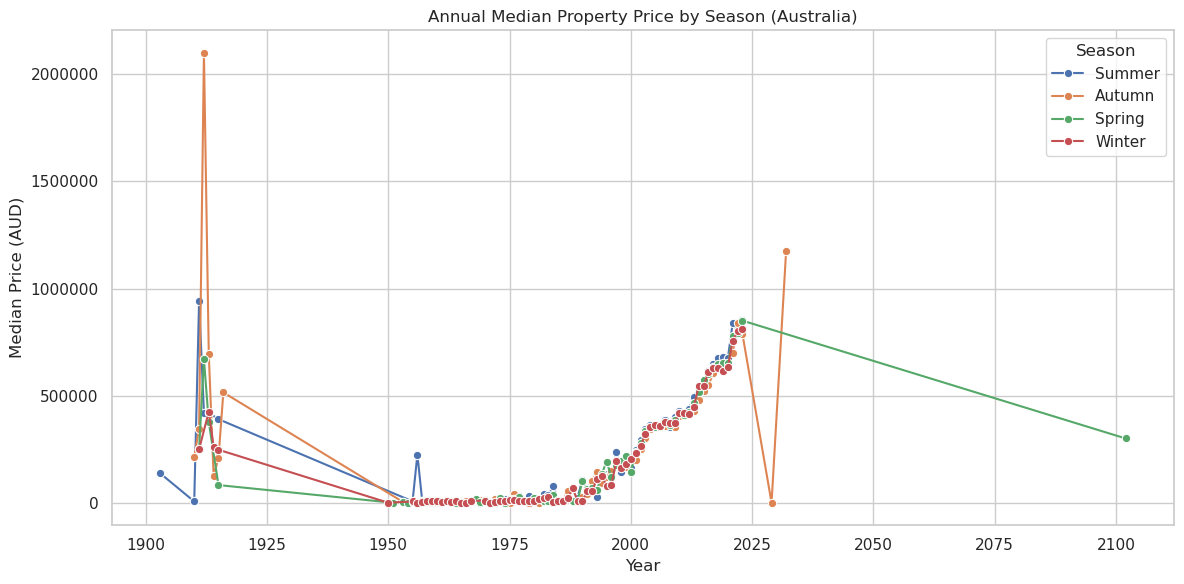

In [57]:
# Plot the Median per Year
# Import Library
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the appropriate `season_start_year`
df_season_median = df_season_median.filter(F.col('season_start_year') >= 1903)

# Convert to DataFrame to easier Visualization
pdf_season_med = df_season_median.toPandas()

sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pdf_season_med,
    x="season_start_year",
    y="median_price",
    hue="season",
    marker="o"
)

plt.title("Annual Median Property Price by Season (Australia)")
plt.xlabel("Year")
plt.ylabel("Median Price (AUD)")
plt.legend(title="Season")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

The trend fluctuates significantly between 1900 and 1920, followed by missing data until around 1950. From approximately 1960 to 1990, the values appear mostly stagnant. There also seems to be a potential data entry error, as the dataset includes a value for the year 2100, which is not realistic.  
  
To accurately represent the trend and ensure relevance, it would be better to focus on the period from 1990 to 2025.

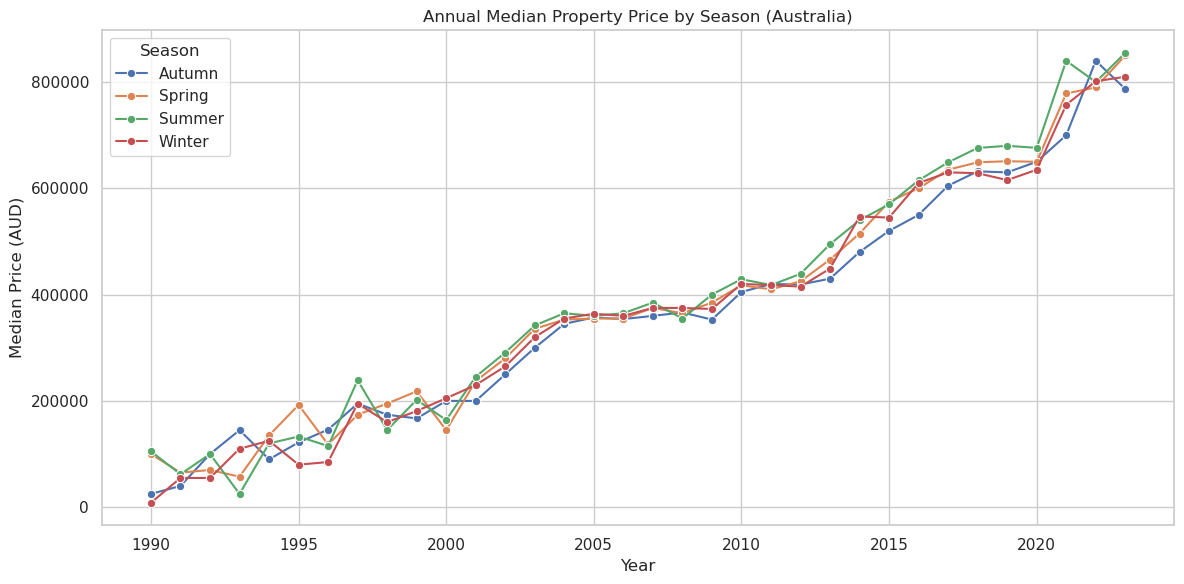

In [58]:
# Filter the appropriate `season_start_year`
df_season_med_90 = df_season_median.filter((F.col('season_start_year') >= 1990) & (F.col('season_start_year') <= 2025))

# Convert to DataFrame to easier Visualization
pdf_season_med_90 = df_season_med_90.toPandas()

sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pdf_season_med_90,
    x="season_start_year",
    y="median_price",
    hue="season",
    marker="o"
)

plt.title("Annual Median Property Price by Season (Australia)")
plt.xlabel("Year")
plt.ylabel("Median Price (AUD)")
plt.legend(title="Season")
plt.grid(True)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

Although there are fluctuations over the years, the overall trend shows that the median property price gradually increases over time.

**2.2.5** (Open Question) Explore the dataset freely and plot one diagram of your choice. Which columns (at least 2) are highly correlated to the sales price? Discuss the steps of your exploration and the results. (No word limit, please keep concise.) 

In [67]:
import pandas as pd

In [65]:
# Sample a fraction of the data due to big size
df_sampled = df_nsw_property.sample(fraction=0.01, seed=42)

# Convert to Pandas DataFrame to Easier Visualization
pdf_sampled = df_sampled.toPandas()

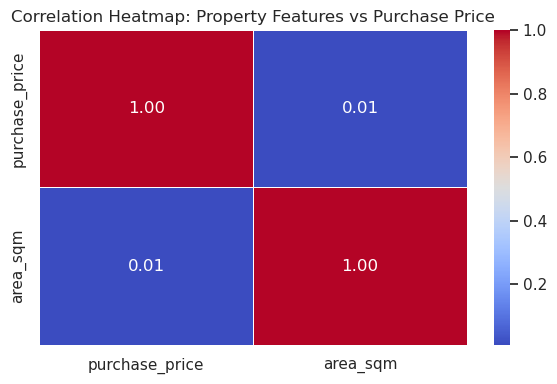

In [68]:
# Convert relevant columns to numeric
pdf_sampled["purchase_price"] = pd.to_numeric(pdf_sampled["purchase_price"], errors="coerce")
pdf_sampled["area_sqm"] = pd.to_numeric(pdf_sampled["area_sqm"], errors="coerce")

# Select only numeric columns
numeric_cols = pdf_sampled[["purchase_price", "area_sqm"]]

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Property Features vs Purchase Price")
plt.tight_layout()
plt.show()

In [90]:
# Clean price and extract year
df_clean = (
    df_sampled
    .withColumn("purchase_price", F.regexp_replace("purchase_price", r"[^0-9.]", "").cast("double"))
    .withColumn("year", F.year("iso_contract_date"))
    .filter(F.col("purchase_price").isNotNull() & F.col("nature_of_property").isNotNull())
)

# Count number of each nature_of_property per year
df_count = (
    df_clean.groupBy("year", "nature_of_property")
    .agg(F.count("*").alias("count_nature"))
)

# Average and median price per year
df_price_stats = (
    df_clean.groupBy("year")
    .agg(
        F.avg("purchase_price").alias("avg_price"),
        F.expr("percentile_approx(purchase_price, 0.5)").alias("median_price")
    )
)

# Join both
df_joined = df_count.join(df_price_stats, on="year", how="inner")

In [74]:
pdf_joined = df_joined.toPandas()

# Optional: pivot to separate counts of nature types into columns
pdf_pivot = pdf_joined.pivot_table(index='year', columns='nature_of_property', values='count_nature', fill_value=0)

# Add price stats
pdf_pivot["avg_price"] = pdf_joined.groupby("year")["avg_price"].first()
pdf_pivot["median_price"] = pdf_joined.groupby("year")["median_price"].first()

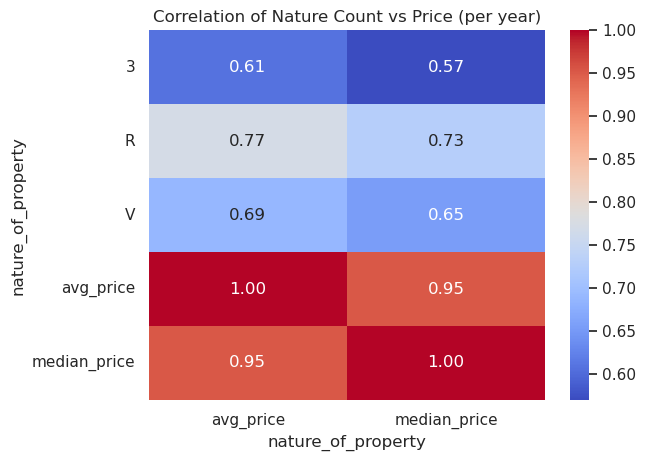

In [75]:
corr = pdf_pivot.corr()
sns.heatmap(corr[["avg_price", "median_price"]], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Nature Count vs Price (per year)")
plt.show()

The yearly frequency of each nature_of_property category is moderately to strongly correlated with both average and median property prices, with nature_of_property = R showing the strongest relationship.

The analysis shows that area_sqm, the only numeric feature in the nsw_property dataset, has a low correlation with purchase_price.

In [85]:
# Define new dataframe to explore primary_purpose correlation
df_purpose_cleaned = (
    df_nsw_purpose
    .withColumn("primary_purpose", classify_purpose_udf("primary_purpose"))
    .withColumn("purchase_price", F.regexp_replace("purchase_price", r"[^0-9.]", "").cast("double"))
    .withColumn("year", F.year("iso_settlement_date"))
    .filter(col("purchase_price").isNotNull() & col("year").isNotNull())
)

# Explode the array column to long format
df_purpose_exploded = df_purpose_cleaned.select(
    explode("primary_purpose").alias("category"),
    "year",
    "purchase_price"
)

# Group by year and category to calculate count, avg, and median
df_purpose_stats = (
    df_purpose_exploded
    .groupBy("year", "category")
    .agg(
        F.count("*").alias("count"),
        F.avg("purchase_price").alias("avg_price"),
        F.expr("percentile_approx(purchase_price, 0.5)").alias("median_price")
    )
    .orderBy("year", "category")
)

In [88]:
pdf_purpose_stats = df_purpose_stats.toPandas()

pivot_count = pdf_purpose_stats.pivot(index="year", columns="category", values="count")

avg_per_year = pdf_purpose_stats.groupby("year")["avg_price"].mean()
median_per_year = pdf_purpose_stats.groupby("year")["median_price"].mean()

pivot_count["avg_price"] = avg_per_year
pivot_count["median_price"] = median_per_year

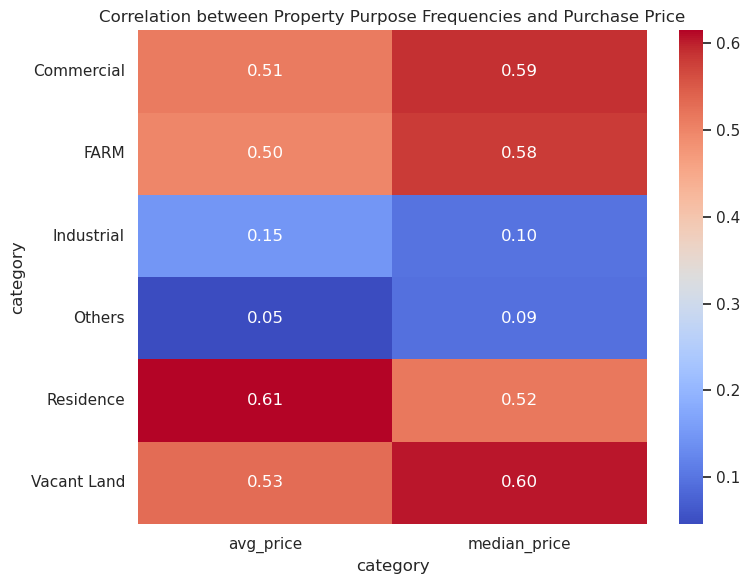

In [89]:
# Plot `primary_purpose` correlation to `purchase_price`
corr = pivot_count.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr[["avg_price", "median_price"]].drop(["avg_price", "median_price"], errors='ignore'),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation between Property Purpose Frequencies and Purchase Price")
plt.tight_layout()
plt.show()

As the dataset contains mostly categorical variables and limited numerical data, aggregation operations (such as mean, median, and frequency counts) are necessary to compute correlations. The analysis shows that:
*  `area_sqm` does not show a significant correlation with `purchase_price`.
*  The annual count of `nature_of_property`, particularly category R, has a relatively strong correlation with both the average and median `purchase_price`.
*  The annual count of `primary_purpose`, especially Residence, correlates well with the average `purchase_price`, while Vacant Land shows a stronger correlation with the median `purchase_price`.
*  In contrast, categories such as Industrial and Others exhibit very low correlation with both average and median `purchase_price`, potentially indicating that these types are either less profitable or too niche for broader market trends.

### Part 3 RDDs vs DataFrame vs Spark SQL (25%) <a class="anchor" name="part-3"></a>
Implement the following complex queries using RDD, DataFrame in SparkSQL separately(choose two). Log the time taken for each query in each approach using the “%%time” built-in magic command in Jupyter Notebook and discuss the performance difference between these 2 approaches of your choice.
(notes: You can write a multi-step query or a single complex query, the choice is yours. You can reuse the data frame in Part 2.)

#### Complex Query:
<pre>
A property investor wants to understand whether the property price and the settlement date are correlated. Here is the conditions:
1)	The investor is only interested in the last 2 years of the dataset.
2)	The investor is looking at houses under $2 million.
3)	Perform a bucketing of the settlement date (settlement – contract date
range (15, 30, 45, 60, 90 days).
4)	Perform a bucketing of property prices in $500K(e.g. 0-$500K, $500K-$1M, $1M-$1.5M, $1.5-$2M)
5)	Count the number of transactions in each combination and print the result in the following format
(Note: It’s fine to count the same property multiple times in this task, it’s based on sales transactions).
(Note: You shall show the full table with 40 rows, 2 years *4 price bucket * 5 settlement bucket; 0 count should be displayed as 0, not omitted.)
</pre>

### a)	Implement the above query using two approaches of your choice separately and print the results. (Note: Outputs from both approaches of your choice are required, and the results should be the same.). 

#### 3.1. Implementation 1 (DataFrame API)

In [92]:
%%time
from pyspark.sql import functions as F

# Clean and prepare the DataFrame
df_3 = (df_nsw_property
    .withColumn("price", F.regexp_replace("purchase_price", r"[^0-9.]", "").cast("double"))
    .withColumn("contract_date", F.to_date("iso_contract_date", "yyyy-MM-dd"))
    .withColumn("settle_date",   F.to_date("iso_settlement_date", "yyyy-MM-dd"))
    .filter(
        F.col("price").isNotNull() & (F.col("price") > 0) &
        F.col("contract_date").isNotNull() & F.col("settle_date").isNotNull()
    )
    .withColumn("settle_days", F.datediff(F.col("settle_date"), F.col("contract_date")))
    .filter(F.col("settle_days") >= 0)
    .withColumn("year", F.year("contract_date"))
)

# Get the last two contract years
max_year = df_3.agg(F.max("year").alias("maxy")).collect()[0]["maxy"]
years_keep = [max_year - 1, max_year]

df_3 = df_3.filter(F.col("year").isin(years_keep))

# Define price buckets (consistent en-dash everywhere)
price_bucket = F.when((F.col("price") < 500_000),   F.lit("0–500K")) \
    .when((F.col("price") < 1_000_000),             F.lit("500K–1M")) \
    .when((F.col("price") < 1_500_000),             F.lit("1M–1.5M")) \
    .when((F.col("price") < 2_000_000),             F.lit("1.5M–2M"))

# Define settlement buckets
settle_bucket = F.when((F.col("settle_days") <= 15),   F.lit("0–15d")) \
    .when((F.col("settle_days") <= 30),                F.lit("16–30d")) \
    .when((F.col("settle_days") <= 45),                F.lit("31–45d")) \
    .when((F.col("settle_days") <= 60),                F.lit("46–60d")) \
    .when((F.col("settle_days") <= 90),                F.lit("61–90d"))

# Apply bucketing
df_3 = (df_3
    .withColumn("price_bucket", price_bucket)
    .withColumn("settle_bucket", settle_bucket)
    .filter(F.col("price_bucket").isNotNull() & F.col("settle_bucket").isNotNull())
)

# Aggregate counts
counts = df_3.groupBy("year", "price_bucket", "settle_bucket") \
    .agg(F.count(F.lit(1)).alias("txn_count"))

# Create full 40-row grid (use en-dash characters!)
years_df = spark.createDataFrame([(y,) for y in years_keep], ["year"])
price_df = spark.createDataFrame([
    ("0–500K",), ("500K–1M",), ("1M–1.5M",), ("1.5M–2M",)
], ["price_bucket"])
settle_df = spark.createDataFrame([
    ("0–15d",), ("16–30d",), ("31–45d",), ("46–60d",), ("61–90d",)
], ["settle_bucket"])

grid = years_df.crossJoin(price_df).crossJoin(settle_df)

# Join and fill missing combinations
result_df = (grid
    .join(counts, on=["year", "price_bucket", "settle_bucket"], how="left")
    .na.fill({"txn_count": 0})
    .orderBy(
        "year",
        F.when(F.col("price_bucket") == "0–500K", 0)
         .when(F.col("price_bucket") == "500K–1M", 1)
         .when(F.col("price_bucket") == "1M–1.5M", 2)
         .otherwise(3),
        F.when(F.col("settle_bucket") == "0–15d", 0)
         .when(F.col("settle_bucket") == "16–30d", 1)
         .when(F.col("settle_bucket") == "31–45d", 2)
         .when(F.col("settle_bucket") == "46–60d", 3)
         .otherwise(4)
    )
)

# Display Result
result_df.show(40, truncate=False)

+----+------------+-------------+---------+
|year|price_bucket|settle_bucket|txn_count|
+----+------------+-------------+---------+
|2023|0–500K      |0–15d        |4053     |
|2023|0–500K      |16–30d       |7648     |
|2023|0–500K      |31–45d       |11014    |
|2023|0–500K      |46–60d       |2551     |
|2023|0–500K      |61–90d       |1662     |
|2023|500K–1M     |0–15d        |3552     |
|2023|500K–1M     |16–30d       |13642    |
|2023|500K–1M     |31–45d       |35375    |
|2023|500K–1M     |46–60d       |9245     |
|2023|500K–1M     |61–90d       |6284     |
|2023|1M–1.5M     |0–15d        |1029     |
|2023|1M–1.5M     |16–30d       |3747     |
|2023|1M–1.5M     |31–45d       |12544    |
|2023|1M–1.5M     |46–60d       |4903     |
|2023|1M–1.5M     |61–90d       |4547     |
|2023|1.5M–2M     |0–15d        |442      |
|2023|1.5M–2M     |16–30d       |1303     |
|2023|1.5M–2M     |31–45d       |5162     |
|2023|1.5M–2M     |46–60d       |2469     |
|2023|1.5M–2M     |61–90d       

#### 3.2. Implementation 2 (Spark SQL)

In [94]:
df_nsw_property.createOrReplaceTempView("raw_tx")

In [95]:
%%time

sql = """
-- Clean and prepare columns
WITH cleaned AS (
  SELECT
    CAST(REGEXP_REPLACE(purchase_price, '[^0-9.]', '') AS DOUBLE) AS price,
    TO_DATE(iso_contract_date, 'yyyy-MM-dd') AS contract_date,
    TO_DATE(iso_settlement_date, 'yyyy-MM-dd') AS settle_date
  FROM raw_tx
  WHERE purchase_price IS NOT NULL
    AND iso_contract_date IS NOT NULL
    AND iso_settlement_date IS NOT NULL
),

-- Filter and calculate derived fields
filtered AS (
  SELECT *,
         DATEDIFF(settle_date, contract_date) AS settle_days,
         YEAR(contract_date) AS year
  FROM cleaned
  WHERE price > 0
    AND DATEDIFF(settle_date, contract_date) >= 0
),

-- Get max and min year (last 2 years)
max_year AS (
  SELECT MAX(year) AS max_y FROM filtered
),
years_keep AS (
  SELECT max_y, max_y - 1 AS min_y FROM max_year
),

-- Apply bucketing
bucketed AS (
  SELECT
    f.year,
    CASE
      WHEN f.price < 500000 THEN '0–500K'
      WHEN f.price < 1000000 THEN '500K–1M'
      WHEN f.price < 1500000 THEN '1M–1.5M'
      WHEN f.price < 2000000 THEN '1.5M–2M'
    END AS price_bucket,
    CASE
      WHEN f.settle_days <= 15 THEN '0–15d'
      WHEN f.settle_days <= 30 THEN '16–30d'
      WHEN f.settle_days <= 45 THEN '31–45d'
      WHEN f.settle_days <= 60 THEN '46–60d'
      WHEN f.settle_days <= 90 THEN '61–90d'
    END AS settle_bucket
  FROM filtered f
  JOIN years_keep yk
    ON f.year IN (yk.max_y, yk.min_y)
  WHERE f.price < 2000000
),

-- Aggregate counts
agg AS (
  SELECT year, price_bucket, settle_bucket, COUNT(*) AS txn_count
  FROM bucketed
  WHERE price_bucket IS NOT NULL AND settle_bucket IS NOT NULL
  GROUP BY year, price_bucket, settle_bucket
),

-- Static dimension tables
years_dim AS (
  SELECT min_y AS year FROM years_keep
  UNION ALL
  SELECT max_y FROM years_keep
),
price_dim AS (
  SELECT '0–500K' AS price_bucket UNION ALL
  SELECT '500K–1M' UNION ALL
  SELECT '1M–1.5M' UNION ALL
  SELECT '1.5M–2M'
),
settle_dim AS (
  SELECT '0–15d' AS settle_bucket UNION ALL
  SELECT '16–30d' UNION ALL
  SELECT '31–45d' UNION ALL
  SELECT '46–60d' UNION ALL
  SELECT '61–90d'
),

-- Create the full 40-row grid
full_grid AS (
  SELECT y.year, p.price_bucket, s.settle_bucket
  FROM years_dim y
  CROSS JOIN price_dim p
  CROSS JOIN settle_dim s
)

-- Final join and ordering
SELECT
  g.year,
  g.price_bucket,
  g.settle_bucket,
  COALESCE(a.txn_count, 0) AS txn_count
FROM full_grid g
LEFT JOIN agg a
  ON a.year = g.year
 AND a.price_bucket = g.price_bucket
 AND a.settle_bucket = g.settle_bucket
ORDER BY
  g.year,
  CASE g.price_bucket
    WHEN '0–500K' THEN 0
    WHEN '500K–1M' THEN 1
    WHEN '1M–1.5M' THEN 2
    ELSE 3
  END,
  CASE g.settle_bucket
    WHEN '0–15d' THEN 0
    WHEN '16–30d' THEN 1
    WHEN '31–45d' THEN 2
    WHEN '46–60d' THEN 3
    ELSE 4
  END
"""

result_sql = spark.sql(sql)
result_sql.show(40, truncate=False)

+----+------------+-------------+---------+
|year|price_bucket|settle_bucket|txn_count|
+----+------------+-------------+---------+
|2023|0–500K      |0–15d        |4053     |
|2023|0–500K      |16–30d       |7648     |
|2023|0–500K      |31–45d       |11014    |
|2023|0–500K      |46–60d       |2551     |
|2023|0–500K      |61–90d       |1662     |
|2023|500K–1M     |0–15d        |3552     |
|2023|500K–1M     |16–30d       |13642    |
|2023|500K–1M     |31–45d       |35375    |
|2023|500K–1M     |46–60d       |9245     |
|2023|500K–1M     |61–90d       |6284     |
|2023|1M–1.5M     |0–15d        |1029     |
|2023|1M–1.5M     |16–30d       |3747     |
|2023|1M–1.5M     |31–45d       |12544    |
|2023|1M–1.5M     |46–60d       |4903     |
|2023|1M–1.5M     |61–90d       |4547     |
|2023|1.5M–2M     |0–15d        |442      |
|2023|1.5M–2M     |16–30d       |1303     |
|2023|1.5M–2M     |31–45d       |5162     |
|2023|1.5M–2M     |46–60d       |2469     |
|2023|1.5M–2M     |61–90d       

### b)	Which one is easier to implement, in your opinion? Log the time taken for each query, and observe the query execution time, among DataFrame and SparkSQL, which is faster and why? Please include proper references. (Maximum 500 words.) 

Between the DataFrame API and Spark SQL, Spark SQL is generally easier to implement, especially for complex queries like joins, filters, groupings, and bucketing. Personally, since I'm more familiar with SQL than Spark or the DataFrame API, writing in Spark SQL feels more intuitive and concise. The syntax is similar to standard SQL, which makes it easier to translate ideas into working code.

However, when comparing performance, the DataFrame API runs faster in practice. Based on the experiment:
*  DataFrame API: Wall time = 40 seconds
*  Spark SQL: Wall time = 1 minute 5 seconds

Even though Spark SQL shows lower CPU usage (22.4 ms vs. 84.3 ms), wall time is more important in distributed systems as it reflects the actual time needed for query execution, including shuffling and task scheduling. The DataFrame API offers more control over these stages, such as caching intermediate results and fine-tuning transformations step-by-step.

The DataFrame API also provides a higher-level abstraction that makes it easier to use for a wider audience (Damji, 2016). Compared to RDDs or relational algebra-like expressions, writing computations in the DataFrame API is simpler and clearer. A major benefit is that syntax and logic errors in DataFrames are caught at compile time, unlike Spark SQL, where errors are only detected at runtime—potentially wasting developer time (Damji, 2016).

Since both DataFrames and Datasets are built on top of Spark SQL, they share the Catalyst query optimizer, which generates optimized logical and physical plans across all languages (R, Python, Scala, Java). These APIs also use Project Tungsten, which improves performance by managing memory off-heap and reducing garbage collection and serialization overhead (Armbrust et al., 2015; Xin & Rosen, 2015).

That said, DataFrame API often has the upper hand in more complex transformations, because it integrates smoothly with other PySpark features and provides flexibility for custom logic and modular development (Bangde, 2024).

**In summary**:
Both APIs benefit from Spark’s Catalyst optimizer and Tungsten engine, which provide speed and performance. But for more complex data processing and better developer control, the DataFrame API is more powerful, thanks to its flexibility, expressiveness in Python, and compile-time safety.

### Some ideas on the comparison

Armbrust, M., Huai, Y., Liang, C., Xin, R., & Zaharia, M. (2015). Deep Dive into Spark SQL’s Catalyst Optimizer. Retrieved September 30, 2017, from https://databricks.com/blog/2015/04/13/deep-dive-into-spark-sqls-catalyst-optimizer.html

Damji, J. (2016). A Tale of Three Apache Spark APIs: RDDs, DataFrames, and Datasets. Retrieved September 28, 2017, from https://databricks.com/blog/2016/07/14/a-tale-of-three-apache-spark-apis-rdds-dataframes-and-datasets.html

Data Flair (2017a). Apache Spark RDD vs DataFrame vs DataSet. Retrieved September 28, 2017, from http://data-flair.training/blogs/apache-spark-rdd-vs-dataframe-vs-dataset

Prakash, C. (2016). Apache Spark: RDD vs Dataframe vs Dataset. Retrieved September 28, 2017, from http://why-not-learn-something.blogspot.com.au/2016/07/apache-spark-rdd-vs-dataframe-vs-dataset.html

Xin, R., & Rosen, J. (2015). Project Tungsten: Bringing Apache Spark Closer to Bare Metal. Retrieved September 30, 2017, from https://databricks.com/blog/2015/04/28/project-tungsten-bringing-spark-closer-to-bare-metal.html

**Reference**

Bhandge, S. (2024, October 22). PySpark SQL API vs DataFrame API: A comprehensive comparison. Medium. Retrieved [09 05, 2025], from https://medium.com/@sagar.bhandge0310/pyspark-sql-api-vs-dataframe-api-a-comprehensive-comparison-aba4dad3d2a9

Databricks. (2025, April 8). struct function. Databricks SQL Language Reference. Retrieved [09 05, 2025], from https://docs.databricks.com/aws/en/sql/language-manual/functions/struct

Spark By {Examples}. (2025, August 21). PySpark explode array and map columns to rows. Spark By {Examples}. Retrieved [09 05, 2025], from https://sparkbyexamples.com/pyspark/pyspark-explode-array-and-map-columns-to-rows/#google_vignette